# Ecommerce Project

In [1]:
# Step 1: Data Ingestion & SQL Database Setup

In [2]:


import pandas as pd
import sqlite3

# 1. Create a dummy dataset (Raw Data)
raw_data = {
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108],
    'CustomerID': [1, 2, 1, 3, 2, 1, 4, 3],
    'Amount': [1200, 450, 800, 1100, 300, 1500, 200, 900],
    'OrderDate': ['2024-01-10', '2024-01-12', '2024-02-10', '2024-02-15', '2024-03-01', '2024-03-05', '2024-03-10', '2024-03-15']
}
df = pd.DataFrame(raw_data)

# 2. Setup the SQL Database connection
conn = sqlite3.connect('mtech_project.db')

# 3. Load data into SQL
df.to_sql('Sales', conn, index=False, if_exists='replace')

print("Step 1 Complete: Database 'mtech_project.db' created and loaded with data.")

Step 1 Complete: Database 'mtech_project.db' created and loaded with data.


# Step 2: Time-Series Analysis (Monthly Revenue Growth)

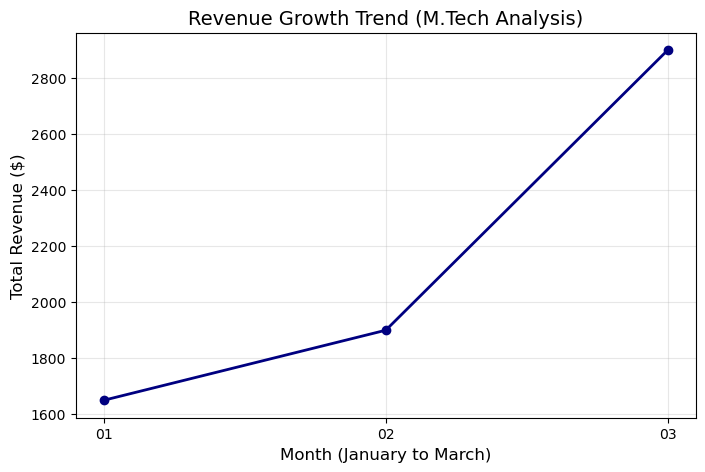

In [3]:
import matplotlib.pyplot as plt

# Pull the analyzed data back to Python for plotting
query = """
SELECT 
    strftime('%m', OrderDate) as Month, 
    SUM(Amount) as MonthlyRevenue 
FROM Sales 
GROUP BY Month
"""
viz_df = pd.read_sql(query, conn)
# Create a professional Line Chart
plt.figure(figsize=(8, 5))
plt.plot(viz_df['Month'], viz_df['MonthlyRevenue'], marker='o', linestyle='-', color='navy', linewidth=2)

# Styling
plt.title('Revenue Growth Trend (M.Tech Analysis)', fontsize=14)
plt.xlabel('Month (January to March)', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

# Step 3: Customer Intelligence & Tier Segmentation

In [4]:
# Python code to calculate and show Customer Tiers
tier_query = """
SELECT 
    CustomerID, 
    SUM(Amount) as TotalSpent,
    CASE 
        WHEN SUM(Amount) > 2000 THEN 'Platinum'
        WHEN SUM(Amount) BETWEEN 1000 AND 2000 THEN 'Gold'
        ELSE 'Silver'
    END as Tier
FROM Sales
GROUP BY CustomerID
"""

tier_df = pd.read_sql(tier_query, conn)
print("--- Customer Tier Results ---")
print(tier_df)
# To see how many customers are in each tier
print("\n--- Tier Count ---")
print(tier_df['Tier'].value_counts())

--- Customer Tier Results ---
   CustomerID  TotalSpent      Tier
0           1        3500  Platinum
1           2         750    Silver
2           3        2000      Gold
3           4         200    Silver

--- Tier Count ---
Tier
Silver      2
Platinum    1
Gold        1
Name: count, dtype: int64
